# 01 — Exploratory Data Analysis & Preprocessing
**Cybersecurity Intrusion Detection**

MOD10: Machine Learning — Winter 2026 — Concordia

---

## Objectives
1. Load and understand the dataset structure
2. Identify distributions, correlations, and patterns
3. Visualize key features (histograms, boxplots, heatmaps)
4. Assess class imbalance
5. Engineer new features and validate their relevance
6. Build the preprocessing pipeline (encoding, scaling, train/test split)

In [1]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import os
FIGURES_DIR = '../reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & First Look

In [2]:
# Load dataset
df = pd.read_csv('../data/cybersecurity_intrusion_data.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head(10)

Dataset shape: 9537 rows x 11 columns

Columns: ['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,SID_00006,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,SID_00007,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,SID_00008,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,SID_00009,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,SID_00010,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


In [3]:
# Data types and info
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'\n=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate session_ids: {df["session_id"].duplicated().sum()}')

=== Data Types ===
session_id              object
network_packet_size      int64
protocol_type           object
login_attempts           int64
session_duration       float64
encryption_used         object
ip_reputation_score    float64
failed_logins            int64
browser_type            object
unusual_time_access      int64
attack_detected          int64
dtype: object

=== Missing Values ===
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

Total missing: 1966

=== Duplicates ===
Duplicate rows: 0
Duplicate session_ids: 0


In [4]:
# Statistical summary — numerical features
df.describe().round(3)

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000,9537.000,9537.000,9537.000,9537.000,9537.000,9537.000
mean,500.431,4.032,792.745,0.331,1.518,0.150,0.447
std,198.379,1.963,786.560,0.177,1.034,0.357,0.497
min,64.000,1.000,0.500,0.002,0.000,0.000,0.000
25%,365.000,3.000,231.953,0.192,1.000,0.000,0.000
50%,499.000,4.000,556.277,0.315,1.000,0.000,0.000
75%,635.000,5.000,1105.381,0.453,2.000,0.000,1.000
max,1285.000,13.000,7190.392,0.924,5.000,1.000,1.000


In [5]:
# Categorical features overview
cat_cols = ['protocol_type', 'encryption_used', 'browser_type']
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- protocol_type ---
protocol_type
TCP     6624
UDP     2406
ICMP     507
Name: count, dtype: int64

--- encryption_used ---
encryption_used
AES    4706
DES    2865
Name: count, dtype: int64

--- browser_type ---
browser_type
Chrome     5137
Firefox    1944
Edge       1469
Unknown     502
Safari      485
Name: count, dtype: int64


## 2. Target Variable Analysis

=== Target Distribution ===
Normal (0): 5273 (55.3%)
Attack (1): 4264 (44.7%)

Imbalance ratio: 1.24:1


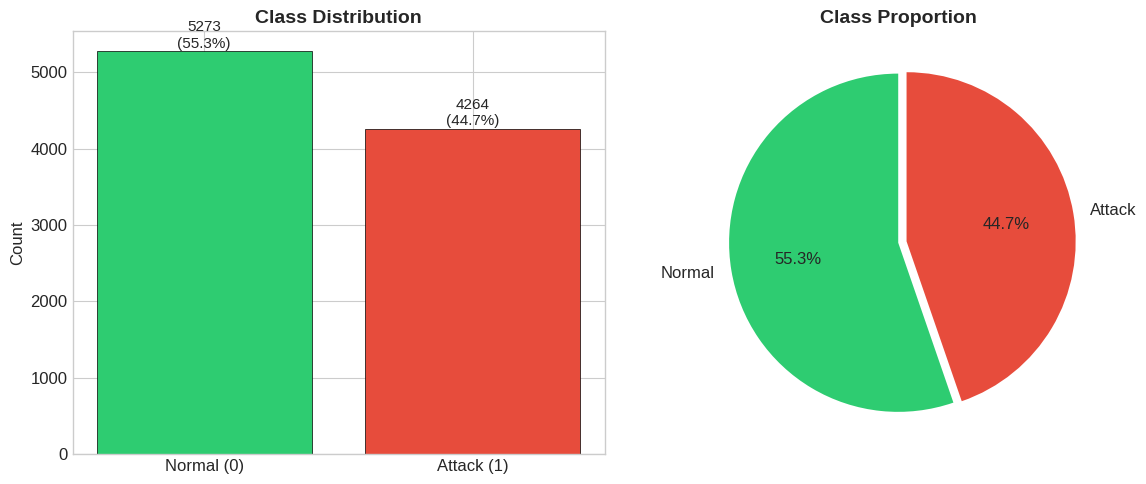

In [6]:
# Class distribution
target_counts = df['attack_detected'].value_counts()
target_pct = df['attack_detected'].value_counts(normalize=True) * 100

print('=== Target Distribution ===')
print(f'Normal (0): {target_counts[0]} ({target_pct[0]:.1f}%)')
print(f'Attack (1): {target_counts[1]} ({target_pct[1]:.1f}%)')
print(f'\nImbalance ratio: {target_counts[0]/target_counts[1]:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Normal (0)', 'Attack (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (count, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, count + 50, f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=['Normal', 'Attack'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numerical Features — Distributions

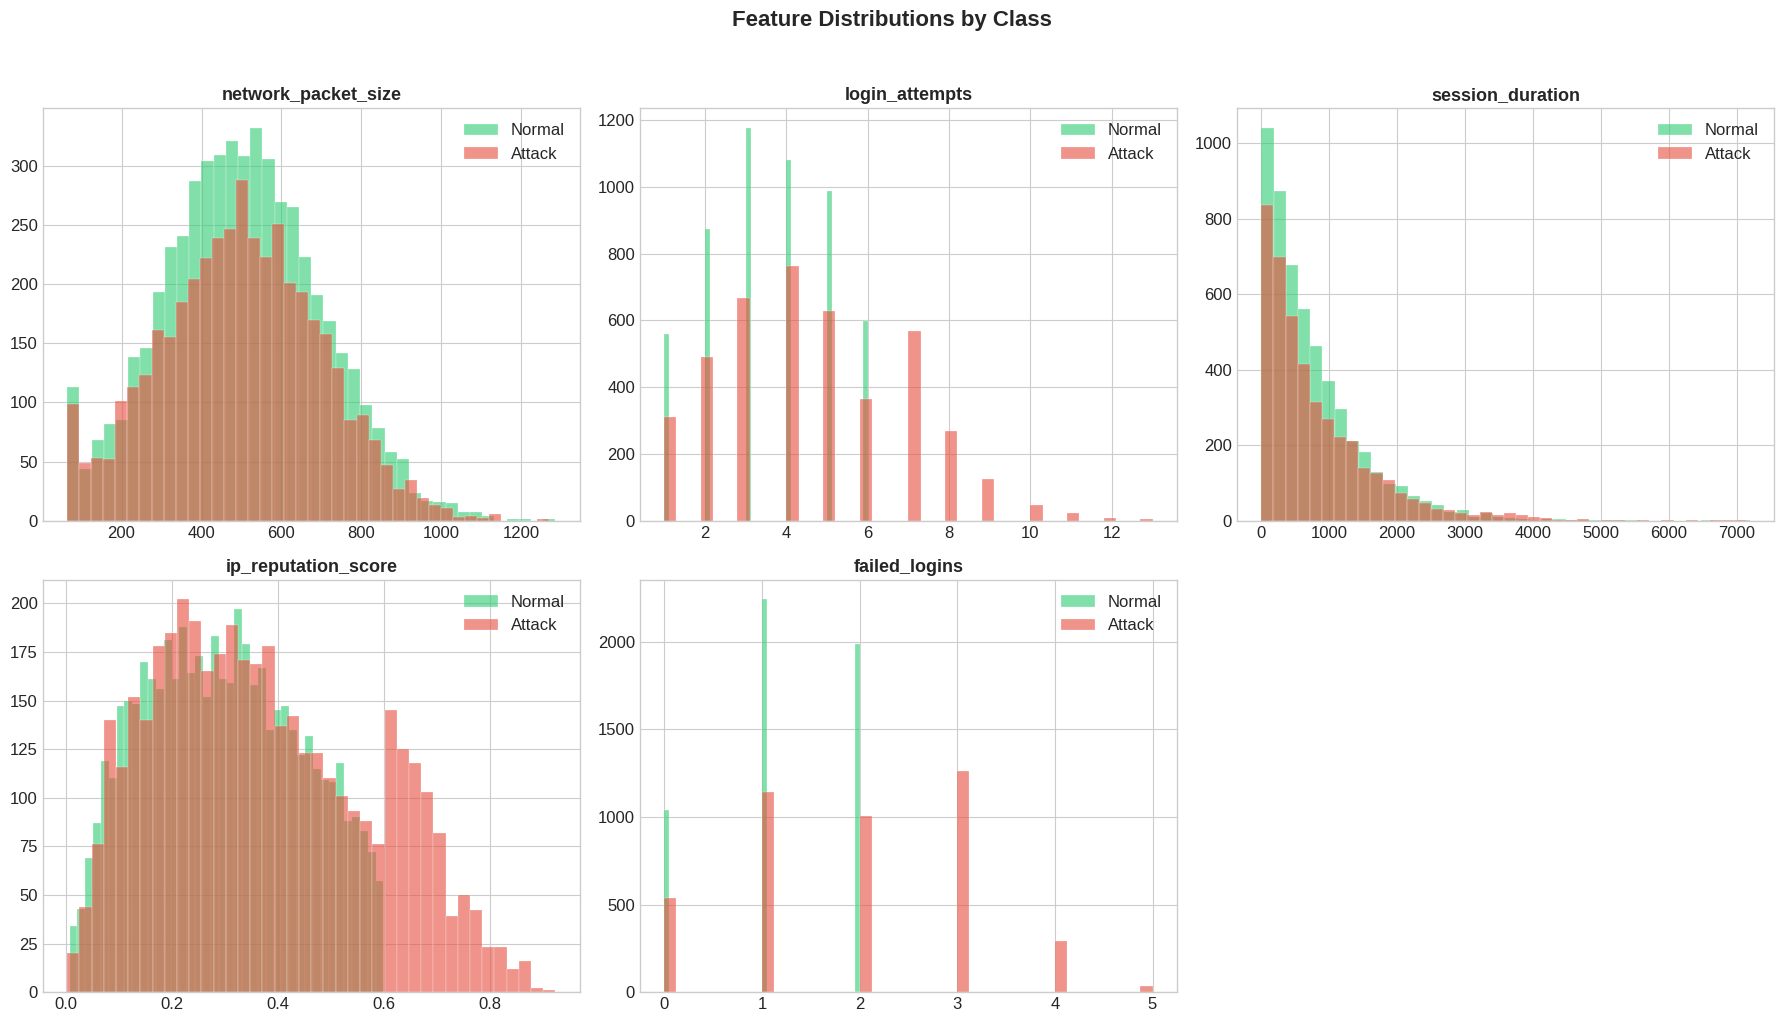

In [7]:
# Histograms for all numerical features, colored by target
num_cols = ['network_packet_size', 'login_attempts', 'session_duration',
            'ip_reputation_score', 'failed_logins']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
        subset = df[df['attack_detected'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('')

# Hide last empty subplot
axes[-1].set_visible(False)

fig.suptitle('Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

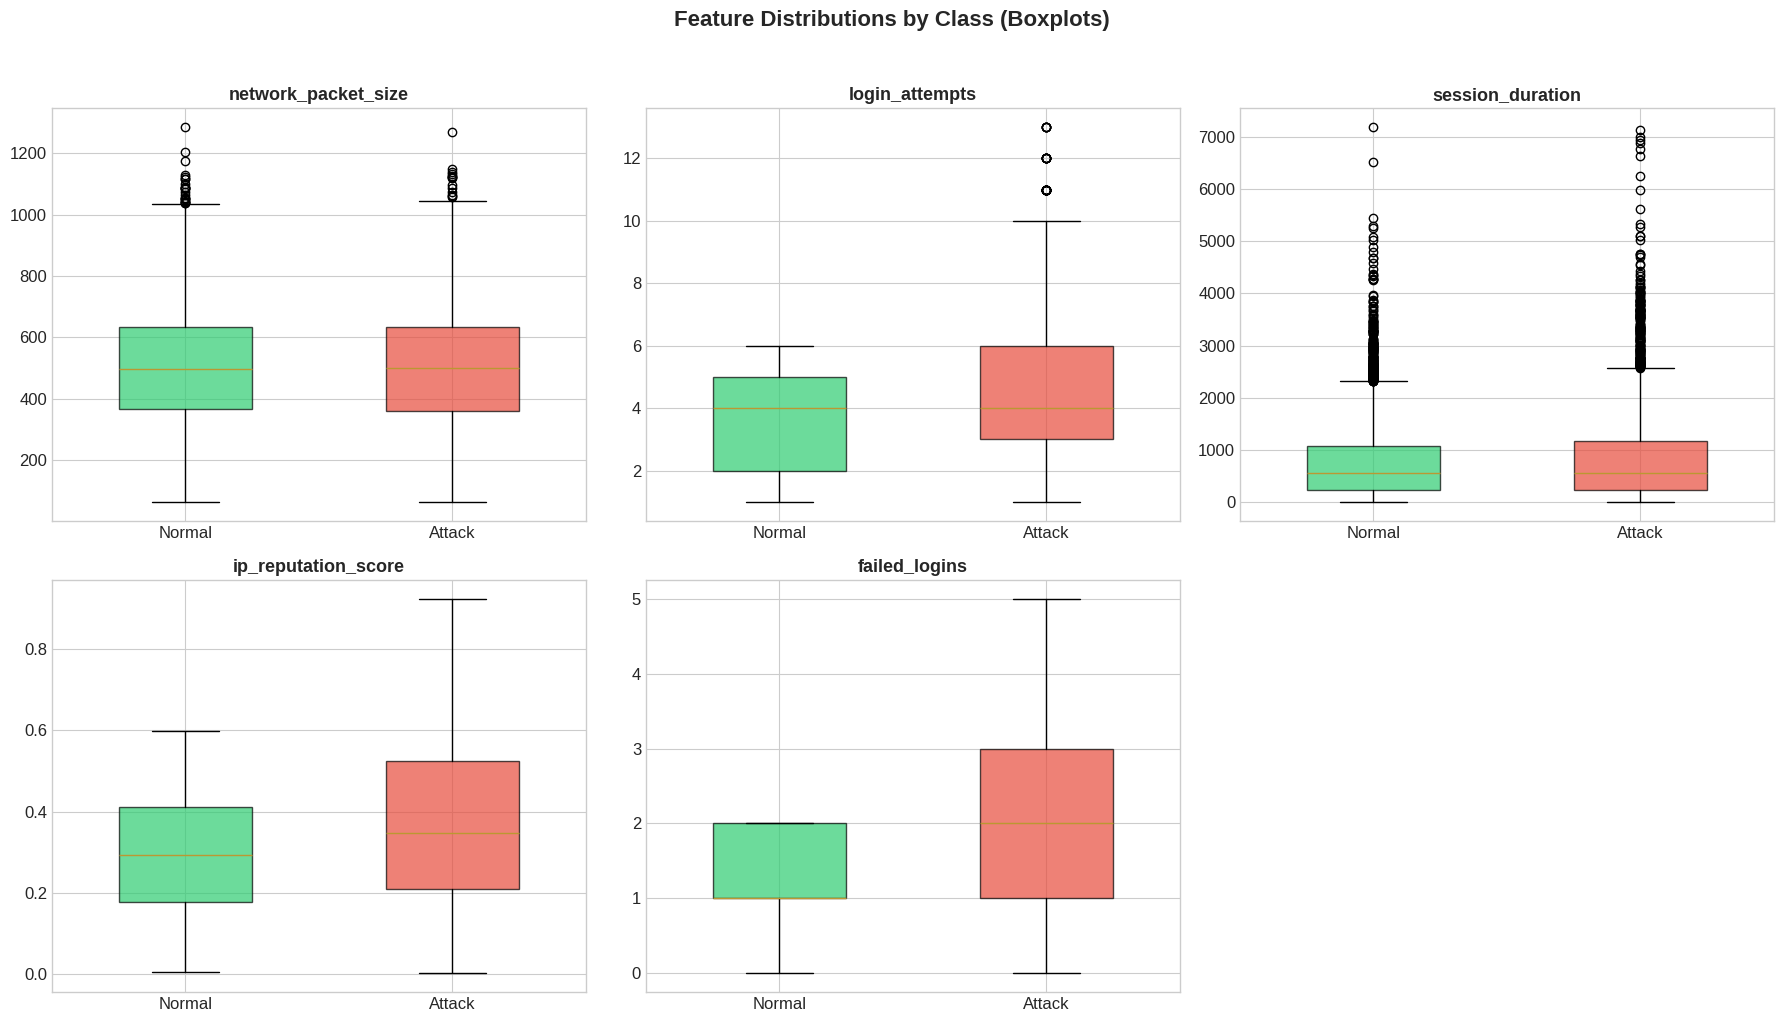

In [8]:
# Boxplots — numerical features by class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_normal = df[df['attack_detected'] == 0][col]
    data_attack = df[df['attack_detected'] == 1][col]
    bp = axes[i].boxplot([data_normal, data_attack], labels=['Normal', 'Attack'],
                         patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    axes[i].set_title(col, fontsize=13, fontweight='bold')

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions by Class (Boxplots)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Categorical Features — Analysis by Class

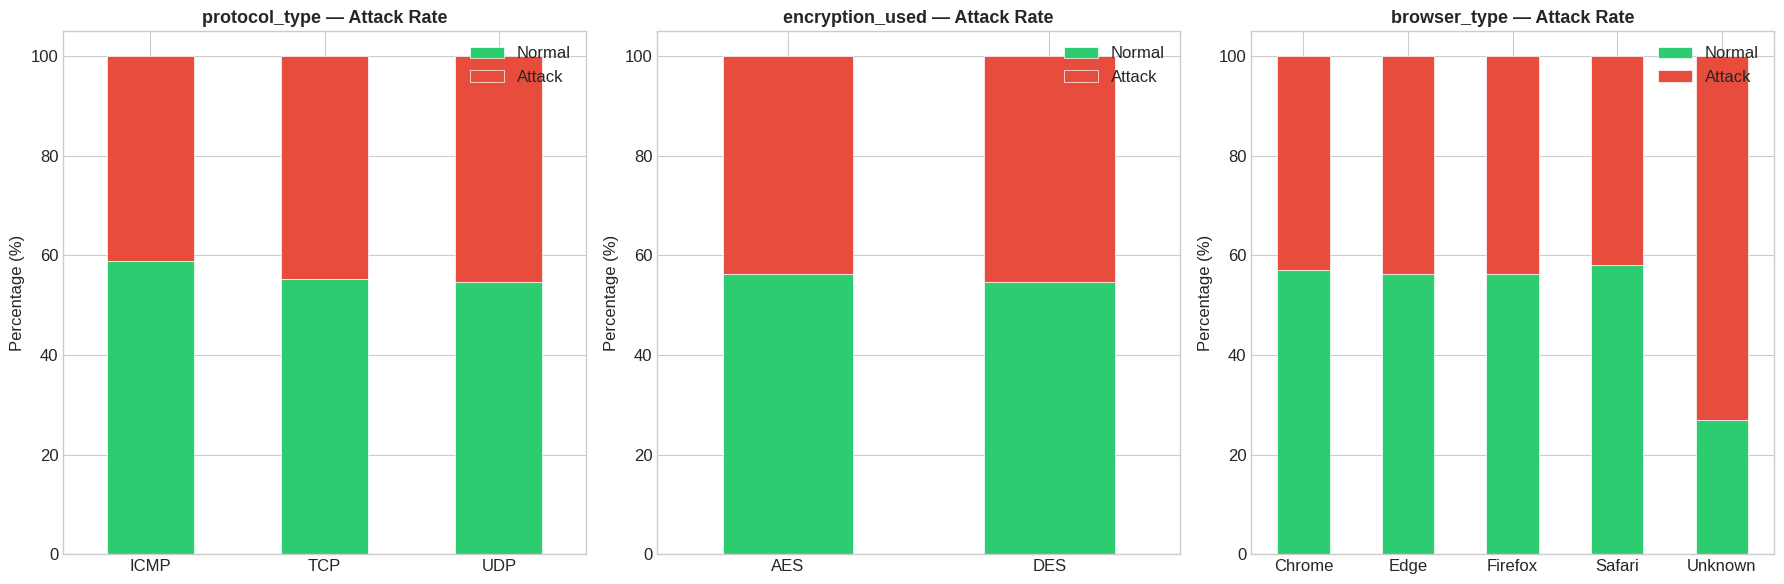

In [9]:
# Countplots for categorical features by class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['attack_detected'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col} — Attack Rate', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].legend(['Normal', 'Attack'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_categorical_attack_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Unusual time access vs attack
ct_time = pd.crosstab(df['unusual_time_access'], df['attack_detected'])
ct_time_pct = pd.crosstab(df['unusual_time_access'], df['attack_detected'], normalize='index') * 100

print('=== Unusual Time Access vs Attack ===')
print(ct_time)
print(f'\nAttack rate when usual time:   {ct_time_pct.loc[0, 1]:.1f}%')
print(f'Attack rate when unusual time: {ct_time_pct.loc[1, 1]:.1f}%')

=== Unusual Time Access vs Attack ===
attack_detected         0     1
unusual_time_access            
0                    4497  3610
1                     776   654

Attack rate when usual time:   44.5%
Attack rate when unusual time: 45.7%


## 5. Correlation Analysis

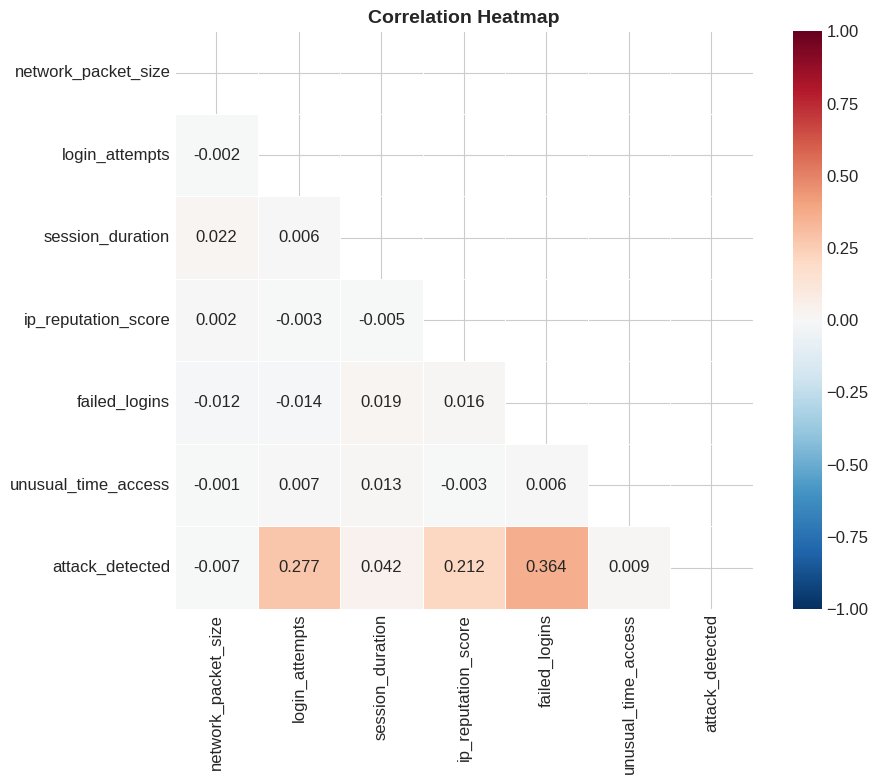

=== Correlation with attack_detected ===
failed_logins          0.3637
login_attempts         0.2773
ip_reputation_score    0.2115
session_duration       0.0416
unusual_time_access    0.0087
network_packet_size   -0.0068
Name: attack_detected, dtype: float64


In [11]:
# Correlation heatmap — numerical features + target
corr_cols = num_cols + ['unusual_time_access', 'attack_detected']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlations with target
print('=== Correlation with attack_detected ===')
target_corr = corr_matrix['attack_detected'].drop('attack_detected').sort_values(key=abs, ascending=False)
print(target_corr.round(4))

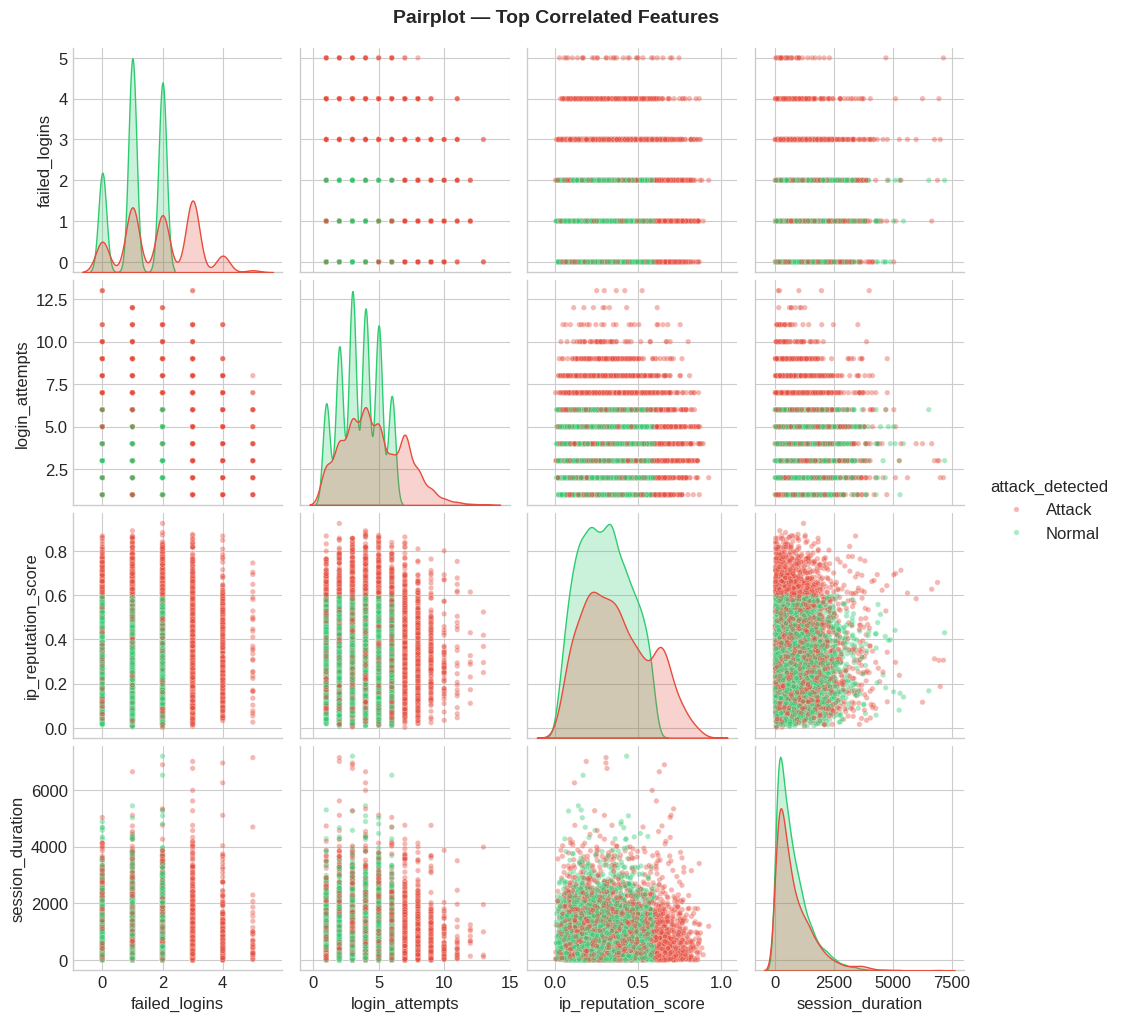

In [12]:
# Pairplot for top correlated features
top_features = target_corr.head(4).index.tolist()
plot_df = df[top_features + ['attack_detected']].copy()
plot_df['attack_detected'] = plot_df['attack_detected'].map({0: 'Normal', 1: 'Attack'})

g = sns.pairplot(plot_df, hue='attack_detected',
                 palette={'Normal': '#2ecc71', 'Attack': '#e74c3c'}, diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 15})
g.figure.suptitle('Pairplot — Top Correlated Features', fontsize=14, fontweight='bold', y=1.02)
plt.savefig(f'{FIGURES_DIR}/06_pairplot_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Engineering

In [13]:
# Create engineered features
df_eng = df.copy()

# Login fail ratio
df_eng['login_fail_ratio'] = np.where(
    df_eng['login_attempts'] > 0,
    df_eng['failed_logins'] / df_eng['login_attempts'],
    0
)

# Packet rate (bytes per second)
df_eng['packet_rate'] = np.where(
    df_eng['session_duration'] > 0,
    df_eng['network_packet_size'] / df_eng['session_duration'],
    0
)

# Composite risk score
df_eng['risk_score'] = (
    df_eng['ip_reputation_score'] * 0.4
    + df_eng['unusual_time_access'] * 0.3
    + df_eng['login_fail_ratio'] * 0.3
)

# High risk IP flag
df_eng['high_risk_ip'] = (df_eng['ip_reputation_score'] > 0.7).astype(int)

print('Engineered features created:')
print(df_eng[['login_fail_ratio', 'packet_rate', 'risk_score', 'high_risk_ip']].describe().round(3))

Engineered features created:
       login_fail_ratio  packet_rate  risk_score  high_risk_ip
count          9537.000     9537.000    9537.000      9537.000
mean              0.520        4.866       0.333         0.028
std               0.564       40.515       0.212         0.166
min               0.000        0.009       0.008         0.000
25%               0.200        0.397       0.185         0.000
50%               0.333        0.846       0.284         0.000
75%               0.667        2.089       0.436         0.000
max               5.000     1554.000       1.934         1.000


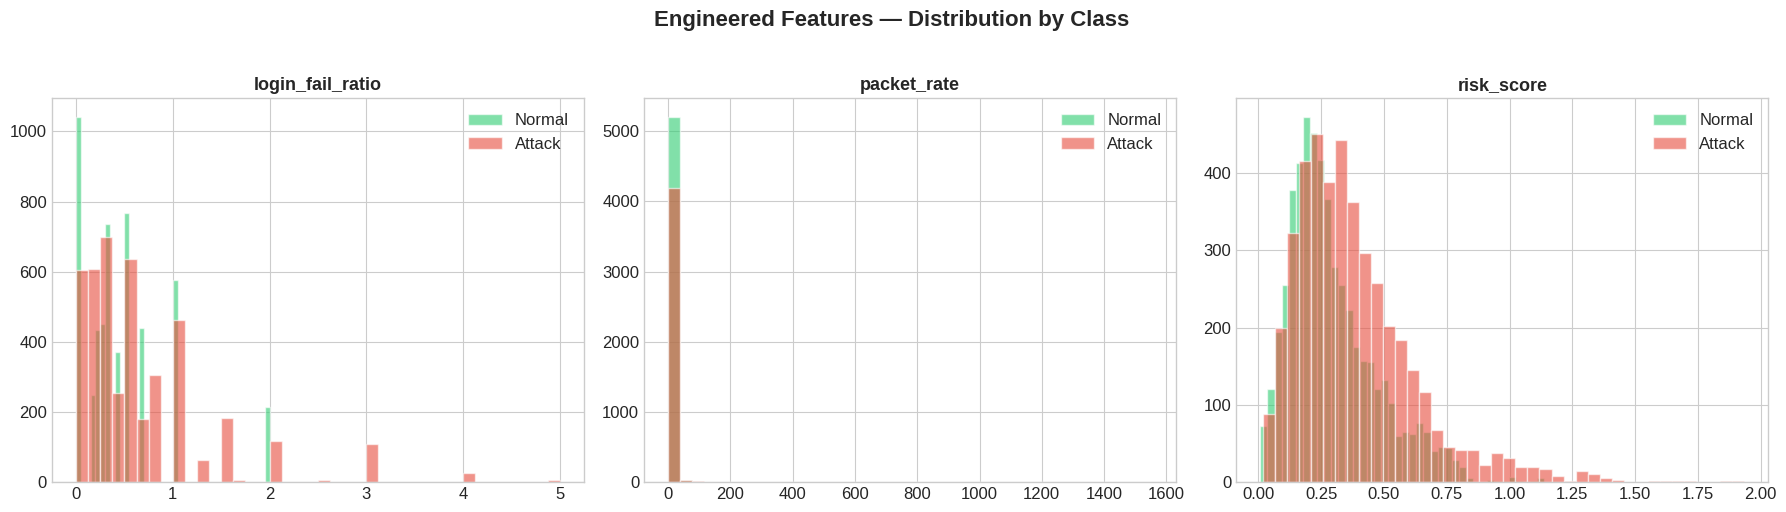

In [14]:
# Visualize engineered features by class
eng_cols = ['login_fail_ratio', 'packet_rate', 'risk_score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(eng_cols):
    for label, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
        subset = df_eng[df_eng['attack_detected'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].legend()

fig.suptitle('Engineered Features — Distribution by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

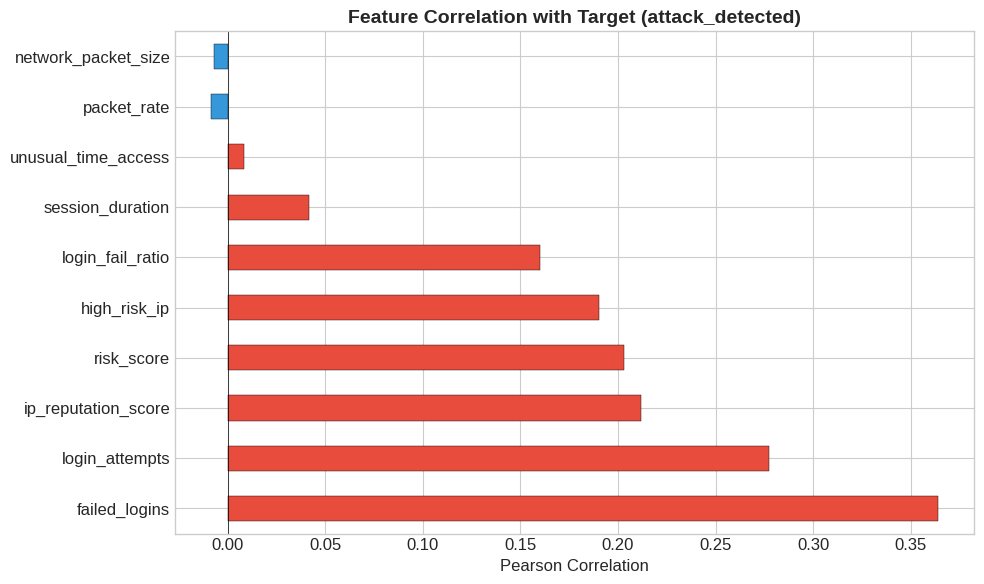


=== All Feature Correlations with Target ===
failed_logins          0.3637
login_attempts         0.2773
ip_reputation_score    0.2115
risk_score             0.2029
high_risk_ip           0.1902
login_fail_ratio       0.1598
session_duration       0.0416
unusual_time_access    0.0087
packet_rate           -0.0082
network_packet_size   -0.0068
Name: attack_detected, dtype: float64


In [15]:
# Correlation of engineered features with target
all_num_cols = num_cols + eng_cols + ['high_risk_ip', 'unusual_time_access', 'attack_detected']
corr_eng = df_eng[all_num_cols].corr()['attack_detected'].drop('attack_detected').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_eng.values]
corr_eng.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.3, ax=ax)
ax.set_title('Feature Correlation with Target (attack_detected)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/08_feature_importance_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== All Feature Correlations with Target ===')
print(corr_eng.round(4))

## 7. Preprocessing Pipeline

In [16]:
# Prepare data for modeling
df_model = df_eng.drop(columns=['session_id'])

# Define feature groups
target = 'attack_detected'
cat_features = ['protocol_type', 'encryption_used', 'browser_type']
num_features = ['network_packet_size', 'login_attempts', 'session_duration',
                'ip_reputation_score', 'failed_logins',
                'login_fail_ratio', 'packet_rate', 'risk_score']
bin_features = ['unusual_time_access', 'high_risk_ip']

X = df_model.drop(columns=[target])
y = df_model[target]

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set:  {X_test.shape[0]} samples')
print(f'\nTrain class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

Train set: 7629 samples
Test set:  1908 samples

Train class distribution:
attack_detected
0    4218
1    3411
Name: count, dtype: int64

Test class distribution:
attack_detected
0    1055
1     853
Name: count, dtype: int64


In [17]:
# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', bin_features),
    ]
)

# Fit on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
cat_encoded_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_encoded_names + bin_features

print(f'Processed train shape: {X_train_processed.shape}')
print(f'Processed test shape:  {X_test_processed.shape}')
print(f'\nTotal features after encoding: {len(all_feature_names)}')
print(f'Feature names: {all_feature_names}')

Processed train shape: (7629, 18)
Processed test shape:  (1908, 18)

Total features after encoding: 18
Feature names: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'login_fail_ratio', 'packet_rate', 'risk_score', 'protocol_type_TCP', 'protocol_type_UDP', 'encryption_used_DES', 'encryption_used_nan', 'browser_type_Edge', 'browser_type_Firefox', 'browser_type_Safari', 'browser_type_Unknown', 'unusual_time_access', 'high_risk_ip']


In [18]:
# Check if SMOTE is needed
print('=== Class Balance Assessment ===')
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'Majority/Minority ratio: {ratio:.2f}')

if ratio > 1.5:
    print('=> Imbalanced dataset detected. SMOTE recommended.')
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)
    print(f'\nBefore SMOTE: {Counter(y_train)}')
    print(f'After SMOTE:  {Counter(y_train_resampled)}')
else:
    print('=> Dataset is reasonably balanced. SMOTE not strictly needed.')
    X_train_resampled, y_train_resampled = X_train_processed, y_train
    print(f'Class counts: {Counter(y_train)}')

=== Class Balance Assessment ===
Majority/Minority ratio: 1.24
=> Dataset is reasonably balanced. SMOTE not strictly needed.
Class counts: Counter({0: 4218, 1: 3411})


## 8. Key EDA Insights Summary

*(This section will be auto-filled after running all cells)*

In [19]:
# === EDA Summary ===
print('=' * 60)
print('EDA SUMMARY — Cybersecurity Intrusion Detection')
print('=' * 60)
print(f'\n1. DATASET: {df.shape[0]} records, {df.shape[1]} features')
print(f'   Missing values: {df.isnull().sum().sum()}')
print(f'   Duplicates: {df.duplicated().sum()}')

print(f'\n2. TARGET DISTRIBUTION:')
for label, name in [(0, 'Normal'), (1, 'Attack')]:
    count = (df['attack_detected'] == label).sum()
    pct = count / len(df) * 100
    print(f'   {name}: {count} ({pct:.1f}%)')

print(f'\n3. TOP CORRELATED FEATURES WITH TARGET:')
for feat, corr_val in corr_eng.head(5).items():
    direction = 'positive' if corr_val > 0 else 'negative'
    print(f'   {feat}: {corr_val:.4f} ({direction})')

print(f'\n4. ENGINEERED FEATURES ADDED: {len(eng_cols) + 1}')
print(f'   login_fail_ratio, packet_rate, risk_score, high_risk_ip')

print(f'\n5. FINAL PROCESSED SHAPE: {X_train_processed.shape[1]} features')
print(f'   Train: {X_train_processed.shape[0]} | Test: {X_test_processed.shape[0]}')

print(f'\n6. FIGURES SAVED TO: {FIGURES_DIR}/')
for f in sorted(os.listdir(FIGURES_DIR)):
    if f.endswith('.png'):
        print(f'   - {f}')

EDA SUMMARY — Cybersecurity Intrusion Detection

1. DATASET: 9537 records, 11 features
   Missing values: 1966
   Duplicates: 0

2. TARGET DISTRIBUTION:
   Normal: 5273 (55.3%)
   Attack: 4264 (44.7%)

3. TOP CORRELATED FEATURES WITH TARGET:
   failed_logins: 0.3637 (positive)
   login_attempts: 0.2773 (positive)
   ip_reputation_score: 0.2115 (positive)
   risk_score: 0.2029 (positive)
   high_risk_ip: 0.1902 (positive)

4. ENGINEERED FEATURES ADDED: 4
   login_fail_ratio, packet_rate, risk_score, high_risk_ip

5. FINAL PROCESSED SHAPE: 18 features
   Train: 7629 | Test: 1908

6. FIGURES SAVED TO: ../reports/figures/
   - 01_target_distribution.png
   - 02_numerical_distributions.png
   - 03_boxplots_by_class.png
   - 04_categorical_attack_rate.png
   - 05_correlation_heatmap.png
   - 06_pairplot_top_features.png
   - 07_engineered_features.png
   - 08_feature_importance_correlation.png
